# Assignment 1: Breast Cancer Classification

Author: Tobias Beekmans  
Master ICT – Software Engineering  
DataOps Specialisation Project – Individual Assignment  
Submission Date: 15.03.2026

In [594]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from scipy.stats import pointbiserialr
from breast_cancer_assignment.dataset import load_data

# Notebook settings
pd.set_option('display.max_columns', None)

# 2.0 Data Understanding

The data understanding phase aims to explore the dataset in order to understand its structure, identify relevant patterns, and detect potential data quality issues.

Following the CRISP-DM methodology, this phase includes collecting the data, describing its structure, verifying data quality, and exploring relationships between features and the target variable.

## 2.1 Data Collection

This section describes the source of the dataset and how it is accessed within the project workflow.

The dataset used in this project is the "Breast Cancer Wisconsin (Diagnostic)" dataset from the UCI Machine Learning Repository. [1]

The dataset contains 569 records [1], which is relatively small compared to many machine learning datasets.

Only a single data source is used in this project. No additional datasets are merged, which simplifies the data integration process and avoids potential inconsistencies between different sources.

Within the project structure, the dataset is managed in two stages:

- raw dataset stored in `data/raw`
- processed datasets generated during the analysis in `data/processed`

Separating raw and processed data supports transparency and reproducibility of the analysis workflow.

To ensure consistent data access across notebooks, the dataset is loaded through the project function `load_data()`, which provides a standardised interface for retrieving the dataset.

In [595]:
df = load_data()

## 2.2 Dataset Description

This section describes the structure and characteristics of the dataset used in the analysis.  
Following the CRISP-DM methodology, the dataset is examined with respect to its size, variable types, and coding scheme.

The dataset consists of 569 observations and 30 numerical features describing morphological characteristics of cell nuclei extracted from digitized images of fine needle aspirate (FNA) samples of breast masses. [1]

Ten core characteristics of the cell nuclei are measured:

- radius
- texture
- perimeter
- area
- smoothness
- compactness
- concavity
- concave points
- symmetry
- fractal dimension

For each characteristic, three different measurements are recorded:

- mean value
- standard error
- worst value

The dataset therefore contains 30 numerical predictor variables describing tumour cell morphology.   In addition to these features, the dataset contains a diagnostic label indicating whether the tumour is malignant or benign. This variable serves as the target variable for the classification task. [1]

The following analysis examines the dataset structure by inspecting its dimensions, variable types, and sample records.

### Table Dimensions

The dimensions of the dataset are inspected to understand the number of records and variables.

In [596]:
rows, columns = df.shape
print(f"Rows: {rows}")
print(f"Columns: {columns}")

Rows: 569
Columns: 31


The dataset contains 569 records and 31 columns in total.

### Data Types

The following output shows the data types of the variables in the dataset.

In [597]:
print(df.dtypes.value_counts())
df.dtypes

float64    30
int64       1
Name: count, dtype: int64


mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

All predictor variables are numerical. The dataset also contains one binary target variable representing the tumour diagnosis.

According to the dataset documentation [1], the encoding of the target variable is defined as:

- 0 = malignant tumour
- 1 = benign tumour

This variable will be used as the prediction target for the machine learning models.

In [598]:
feature_df = df.select_dtypes(include='number').drop(columns=['target'])
feature_columns = feature_df.columns
n_samples= len(df)

### Sample Data

To obtain an initial understanding of the dataset, a small sample of observations is displayed.

In [599]:
df.sample(10)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
460,17.08,27.15,111.20,930.9,0.09898,0.11100,0.10070,0.06431,0.1793,0.06281,0.9291,1.1520,6.051,115.20,0.008740,0.022190,0.027210,0.014580,0.02045,0.004417,22.96,34.49,152.10,1648.0,0.1600,0.2444,0.26390,0.15550,0.3010,0.09060,0
47,13.17,18.66,85.98,534.6,0.11580,0.12310,0.12260,0.07340,0.2128,0.06777,0.2871,0.8937,1.897,24.25,0.006532,0.023360,0.029050,0.012150,0.01743,0.003643,15.67,27.95,102.80,759.4,0.1786,0.4166,0.50060,0.20880,0.3900,0.11790,0
75,16.07,19.65,104.10,817.7,0.09168,0.08424,0.09769,0.06638,0.1798,0.05391,0.7474,1.0160,5.029,79.25,0.010820,0.022030,0.035000,0.018090,0.01550,0.001948,19.77,24.56,128.80,1223.0,0.1500,0.2045,0.28290,0.15200,0.2650,0.06387,0
440,10.97,17.20,71.73,371.5,0.08915,0.11130,0.09457,0.03613,0.1489,0.06640,0.2574,1.3760,2.806,18.15,0.008565,0.046380,0.064300,0.017680,0.01516,0.004976,12.36,26.87,90.14,476.4,0.1391,0.4082,0.47790,0.15550,0.2540,0.09532,1
426,10.48,14.98,67.49,333.6,0.09816,0.10130,0.06335,0.02218,0.1925,0.06915,0.3276,1.1270,2.564,20.77,0.007364,0.038670,0.052630,0.012640,0.02161,0.004830,12.13,21.57,81.41,440.4,0.1327,0.2996,0.29390,0.09310,0.3020,0.09646,1
269,10.71,20.39,69.50,344.9,0.10820,0.12890,0.08448,0.02867,0.1668,0.06862,0.3198,1.4890,2.230,20.74,0.008902,0.047850,0.073390,0.017450,0.02728,0.007610,11.69,25.21,76.51,410.4,0.1335,0.2550,0.25340,0.08600,0.2605,0.08701,1
418,12.70,12.17,80.88,495.0,0.08785,0.05794,0.02360,0.02402,0.1583,0.06275,0.2253,0.6457,1.527,17.37,0.006131,0.012630,0.009075,0.008231,0.01713,0.004414,13.65,16.92,88.12,566.9,0.1314,0.1607,0.09385,0.08224,0.2775,0.09464,1
302,20.09,23.86,134.70,1247.0,0.10800,0.18380,0.22830,0.12800,0.2249,0.07469,1.0720,1.7430,7.804,130.80,0.007964,0.047320,0.076490,0.019360,0.02736,0.005928,23.68,29.43,158.80,1696.0,0.1347,0.3391,0.49320,0.19230,0.3294,0.09469,0
166,10.80,9.71,68.77,357.6,0.09594,0.05736,0.02531,0.01698,0.1381,0.06400,0.1728,0.4064,1.126,11.48,0.007809,0.009816,0.010990,0.005344,0.01254,0.002120,11.60,12.02,73.66,414.0,0.1436,0.1257,0.10470,0.04603,0.2090,0.07699,1
27,18.61,20.25,122.10,1094.0,0.09440,0.10660,0.14900,0.07731,0.1697,0.05699,0.8529,1.8490,5.632,93.54,0.010750,0.027220,0.050810,0.019110,0.02293,0.004217,21.31,27.26,139.90,1403.0,0.1338,0.2117,0.34460,0.14900,0.2341,0.07421,0


The sample shows that each observation contains numerical measurements describing cell properties together with the corresponding diagnostic label.

## 2.3 Data Quality Verification

Following the CRISP-DM methodology, the data quality verification step examines the dataset for potential issues that may affect later modeling stages. Typical data quality problems include missing values, duplicate records, invalid values, measurement errors or inconsistencies in the data representation.

Identifying such issues at an early stage helps ensure that the dataset is suitable for machine learning tasks and prevents modeling results from being affected by data errors or inconsistencies. [2]

### Missing Values

The dataset is checked for missing values to verify that all observations contain complete information for each feature. Missing values may indicate data collection issues or incomplete measurements and can influence model performance if not handled properly.

In [600]:
missing_values = df.isna().sum()
missing_values_percent = df.isna().mean() * 100

missing_values_df = pd.DataFrame({
    'Missing Values [abs]': missing_values,
    'Missing Values [%]': missing_values_percent
})

print(f"Total missing values: {missing_values.sum()}")
missing_values_df.round(2)

Total missing values: 0


,Missing Values [abs],Missing Values [%]
mean radius,0,0.0
mean texture,0,0.0
mean perimeter,0,0.0
mean area,0,0.0
mean smoothness,0,0.0
mean compactness,0,0.0
mean concavity,0,0.0
mean concave points,0,0.0
mean symmetry,0,0.0
mean fractal dimension,0,0.0


The inspection shows that the dataset does not contain missing values.   All observations have complete feature information, meaning no imputation or removal of records is required.

### Duplicates

Duplicate observations are checked to ensure that the dataset does not contain repeated entries that could bias the statistical analysis or model training.

In [601]:
duplicates = df.duplicated().sum()
print(f"Total Duplicates: {duplicates}")

Total Duplicates: 0


The dataset does not contain duplicate records. Each observation therefore represents a unique tumour sample.

### Invalid Values

The dataset is examined for potential invalid or implausible values. In medical measurement data, certain values may be impossible or unlikely, such as negative measurements for physical properties like area, radius, or perimeter. Conducting plausibility checks helps detect potential measurement errors or incorrect data encoding.

In [602]:
negatives = (df.select_dtypes(include='number') < 0).any()
neg_columns = negatives[negatives].index.tolist()
print(f"Columns with negative values: {neg_columns if neg_columns else 'None'}")

Columns with negative values: None


No invalid negative values were detected in the dataset. All feature values fall within reasonable numerical ranges and appear consistent with the expected measurement types.

### Outlier Detection

Outliers are examined to identify extreme observations that may influence statistical analysis or machine learning models.

Two statistical methods are widely used to detect potential outliers in numerical datasets [3]:

- **Interquartile Range (IQR):** The IQR method defines outliers as observations falling below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR (where IQR represents the interquartile range = Q3 − Q1)

- **Z-Score:** Observations with an absolute Z-Score greater than 3 are considered potential outliers (assumption of a normal distribution: approximately 99.7% of observations lie within three standard deviations of the mean)

Only numerical predictor variables are included in the outlier analysis. The target variable is excluded because it represents the diagnostic label.

In [603]:
# IQR Outlier
iqr_outliers = {}

for col in feature_columns:
    q1, q3 = feature_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    iqr_outliers[col] = ((feature_df[col] < lower) | (feature_df[col] > upper)).sum()
iqr_outliers = pd.Series(iqr_outliers)

iqr_percentage = (iqr_outliers / n_samples * 100).round(2)

# Z-Score Outlier
z_scores = feature_df.apply(zscore)
z_outliers = (abs(z_scores) > 3).sum()
z_percentage = (z_outliers / n_samples * 100).round(2)

# Outlier Dataframe
outlier_df = pd.DataFrame({
    'IQR Outliers': iqr_outliers,
    'IQR Outliers (%)': iqr_percentage,
    'Z-Score Outliers': z_outliers,
    'Z-Score Outliers (%)': z_percentage
})

print("Top 10 Features by IQR Outliers")
display(outlier_df.sort_values('IQR Outliers', ascending=False).head(10))

print("Top 10 Features by Z-Score Outliers")
display(outlier_df.sort_values('Z-Score Outliers', ascending=False).head(10))

Top 10 Features by IQR Outliers


,IQR Outliers,IQR Outliers (%),Z-Score Outliers,Z-Score Outliers (%)
area error,65,11.42,6,1.05
radius error,38,6.68,7,1.23
perimeter error,38,6.68,8,1.41
worst area,35,6.15,10,1.76
smoothness error,30,5.27,7,1.23
compactness error,28,4.92,12,2.11
fractal dimension error,28,4.92,10,1.76
symmetry error,27,4.75,11,1.93
mean area,25,4.39,8,1.41
worst fractal dimension,24,4.22,9,1.58


Top 10 Features by Z-Score Outliers


,IQR Outliers,IQR Outliers (%),Z-Score Outliers,Z-Score Outliers (%)
compactness error,28,4.92,12,2.11
symmetry error,27,4.75,11,1.93
worst compactness,16,2.81,10,1.76
worst area,35,6.15,10,1.76
fractal dimension error,28,4.92,10,1.76
texture error,20,3.51,9,1.58
worst symmetry,23,4.04,9,1.58
worst fractal dimension,24,4.22,9,1.58
mean compactness,16,2.81,9,1.58
mean concavity,18,3.16,9,1.58


The outlier analysis shows that several variables contain observations outside typical statistical ranges. 

**IQR:**  
The IQR method identifies the highest number of outliers in variables related to measurement variability. For example: the feature `area error` contains 65 observations identified as outliers using the IQR method, corresponding to approximately 11.4% of the dataset. Other variables (such as `radius error`, `perimeter error`, `worst area`) also reveal relatively high numbers of extreme values. 

Many of these outliers occur in variables representing measurement variability (features ending in "error") or the largest observed values of tumour characteristics (features labeled with "worst"). These variables represent measurement variability or extreme tumour characteristics and therefore tend to show larger deviations. [4]

**Z-Score:**  
The Z-score method highlights a similar pattern. Variables such as `compactness error`, `symmetry error`, and `worst compactness` appear among the features with the highest number of extreme observations, indicating that several shape-related tumour characteristics also contain values that deviate strongly from the dataset mean.

In biomedical datasets such extreme observations do not necessarily represent data errors. They may reflect biological variability in tumour morphology or measurement variability in medical imaging data. [5]

Removing these observations without domain-specific justification may lead to the loss of relevant information. For this reason potential outliers are not removed at this stage. Their influence will instead be addressed during later preprocessing steps, for example through feature scaling or the use of machine learning models that are less sensitive to extreme values.

## 2.4 Data Exploration

This section explores patterns and relationships within the dataset in order to better understand the behaviour of the features and their connection to the target variable.

Exploratory analysis helps to identify potentially relevant attributes, reveal hidden structures in the data, and formulate hypotheses about which variables may be most useful for the classification task. [2]

The analysis focuses on descriptive statistics, class distribution, correlations between features, and relationships between features and the diagnostic outcome.

### 2.4.1 Statistical Overview

Descriptive statistics are calculated to obtain an overview of the numerical properties of the dataset.

Such statistics help to understand the scale, variability, and distribution of the features and provide an initial indication of potential issues such as skewed distributions or large differences in feature magnitude. These insights are important for later preprocessing steps such as feature scaling or transformation.

### Summary Statistics

Basic statistical measures are calculated to understand the range, central tendency, and spread of the numerical variables.

In [604]:
df.describe().round(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,0.41,1.22,2.87,40.34,0.01,0.03,0.03,0.01,0.02,0.00,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,0.63
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,0.28,0.55,2.02,45.49,0.00,0.02,0.03,0.01,0.01,0.00,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,0.48
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,0.11,0.36,0.76,6.80,0.00,0.00,0.00,0.00,0.01,0.00,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,0.00
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,0.23,0.83,1.61,17.85,0.01,0.01,0.02,0.01,0.02,0.00,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,0.00
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,0.32,1.11,2.29,24.53,0.01,0.02,0.03,0.01,0.02,0.00,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,1.00
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,0.48,1.47,3.36,45.19,0.01,0.03,0.04,0.01,0.02,0.00,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,1.00
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,2.87,4.88,21.98,542.20,0.03,0.14,0.40,0.05,0.08,0.03,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,1.00


The summary statistics provide an overview of the numerical properties of the dataset and reveal differences in feature scale and variability.

Several variables describing tumour size show larger numerical ranges than other measurements. Example: the feature `mean area` has an average value of approximately 655 with a maximum value above 2500, while features such as `mean smoothness` have values close to 0.1. Such differences in magnitude indicate that the dataset contains features with very different numerical scales.

In addition, some variables show high variability. For instance, the feature `area error` has a mean value of 40.34 with a standard deviation of 45.49 and a maximum value of 542.20, indicating variation across tumour samples.

Large differences between minimum and maximum values can also be observed in features such as `worst area`, which ranges from approximately 185 to over 4250. These wide ranges suggest strong variability in tumour characteristics within the dataset.

These observations indicate that feature scaling may be necessary before training certain machine learning algorithms, particularly models that rely on for example distance calculations.

### Additional Statistical Metrics

Additional statistical metrics are calculated to further analyze the distributional characteristics of the dataset features. These statistics help to better understand the properties of the features and support later modeling decisions, such as feature scaling or the selection of algorithms that are robust to non-normal data distributions.

Measures such as variance, skewness, and kurtosis provide information about variability, asymmetry, and the tail behaviour of feature distributions. [6]

In [605]:
median = df.median(numeric_only=True)
variance = df.var(numeric_only=True)
skew = df.skew(numeric_only=True)
kurt = df.kurtosis(numeric_only=True)
iqr = df.quantile(0.75, numeric_only=True) - df.quantile(0.25, numeric_only=True)

stats_df = pd.DataFrame({
    'Median': median,
    'Variance': variance,
    'Skewness': skew,
    'Kurtosis': kurt,
    'IQR': iqr
})

stats_df.round(2)

,Median,Variance,Skewness,Kurtosis,IQR
mean radius,13.37,12.42,0.94,0.85,4.08
mean texture,18.84,18.50,0.65,0.76,5.63
mean perimeter,86.24,590.44,0.99,0.97,28.93
mean area,551.10,123843.55,1.65,3.65,362.40
mean smoothness,0.10,0.00,0.46,0.86,0.02
mean compactness,0.09,0.00,1.19,1.65,0.07
mean concavity,0.06,0.01,1.40,2.00,0.10
mean concave points,0.03,0.00,1.17,1.07,0.05
mean symmetry,0.18,0.00,0.73,1.29,0.03
mean fractal dimension,0.06,0.00,1.30,3.01,0.01


**Skewness:**  
Several variables exhibit noticeable positive skewness, indicating that their distributions contain a larger number of small values and a smaller number of extreme observations. This pattern is particularly visible in features such as `area error`, `concavity error`, and `perimeter error`, which show strong skewness values.

**Kurtosis:**  
High kurtosis values can also be observed for several variables, suggesting the presence of heavy-tailed distributions. Such distributions contain more extreme observations than would be expected under a normal distribution, which is consistent with the outlier patterns observed earlier in the analysis.

**IQR:**  
The interquartile range highlights differences in variability within the central 50% of the observations. Variables related to tumour size, such as `mean area` and `worst area`, exhibit substantially larger IQR values compared to other measurements, indicating higher variability in tumour size characteristics across samples.

These observations suggest that the dataset contains non-normally distributed variables and varying levels of dispersion, which may influence model behaviour and should be considered during later preprocessing steps such as scaling or transformation.

### 2.4.2 Target Distribution

The distribution of the target variable is determined to assess whether the dataset is balanced between malignant and benign tumour cases.

Class imbalance can affect model performance and evaluation metrics.

              Count  Percentage
target_label                   
Benign          357        62.7
Malignant       212        37.3


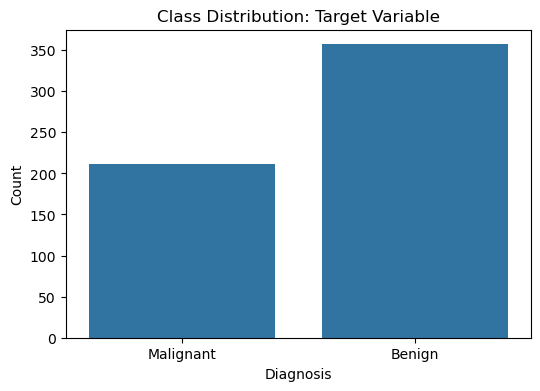

In [606]:
df['target_label'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

target_counts = df['target_label'].value_counts()
target_percent = (target_counts / len(df) * 100).round(1)

print(pd.DataFrame({"Count": target_counts, "Percentage": target_percent}))

plt.figure(figsize=(6,4))
sns.countplot(x='target_label', data=df)

plt.title('Class Distribution: Target Variable')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

The target distribution shows that benign tumour cases occur more frequently than malignant cases in the dataset. The dataset contains 357 benign cases (62.7%) and 212 malignant cases (37.3%).

Although the dataset is not perfectly balanced, the class distribution shows only a moderate imbalance and both classes are sufficiently represented for training classification models.

Class imbalance should be considered when evaluating model performance. In medical diagnosis tasks, correctly identifying malignant tumours is particularly important. Therefore, evaluation metrics such as recall, precision, and the confusion matrix will be considered in addition to overall accuracy.

### 2.4.3 Feature Correlation

A correlation matrix is calculated to examine relationships between the numerical features.

Highly correlated variables may capture similar information about tumour morphology. Such redundancy can lead to multicollinearity [6], which may influence certain machine learning algorithms, particularly linear models and distance-based methods. In this cases feature selection or regularisation techniques may help reduce redundancy and improve model stability.

#### Correlation Heatmap

The correlation heatmap visualises pairwise relationships between all numerical features. To improve readability, only the upper triangle of the correlation matrix is displayed, since the lower triangle would contain duplicate information.

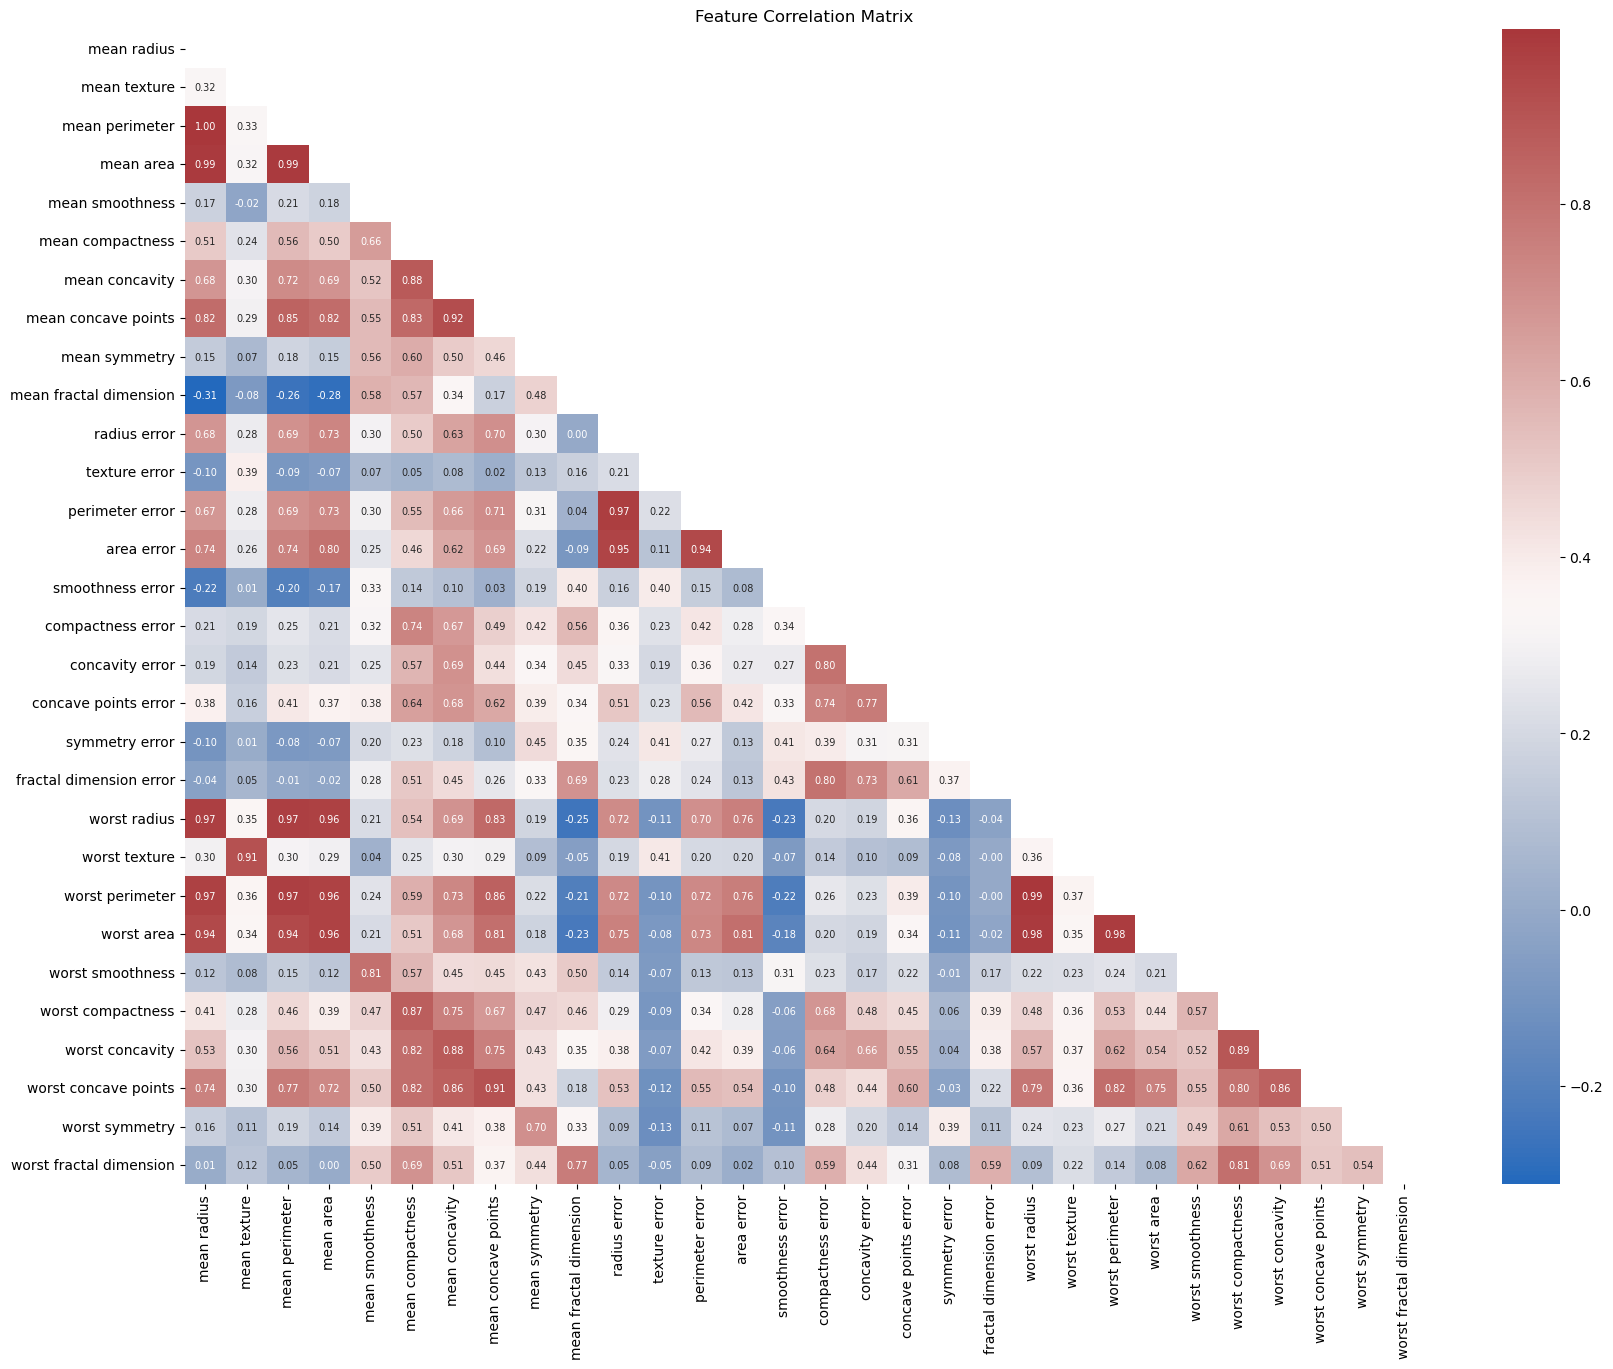

In [607]:
corr_matrix = feature_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(20,15))
sns.heatmap(corr_matrix, annot=True, mask=mask, fmt='.2f', annot_kws={"size": 7}, cmap='vlag')

plt.title("Feature Correlation Matrix")
plt.show()

The heatmap reveals several strong correlations between groups of variables.

Features describing tumour size show very high positive correlations. Measurements such as `mean radius`, `mean perimeter`, and `mean area` increase together because they represent related properties of the tumour cells.
The corresponding “worst” measurements (`worst radius`, `worst perimeter`, `worst area`) also show strong correlations, indicating that extreme tumour characteristics follow similar geometric relationships.

These patterns suggest that several variables capture overlapping information about tumour morphology.

#### Correlated Feature Pairs

To determine feature redundancy, pairs of variables with very high absolute correlation values are identified.

In [608]:
corr_matrix_abs = feature_df.corr().abs()

# Get upper triangle of the correlation matrix
upper_triangle = corr_matrix_abs.where(np.triu(np.ones_like(corr_matrix_abs), k=1).astype(bool))

high_corr_pairs = (upper_triangle.stack().sort_values(ascending=False).reset_index())
high_corr_pairs.columns = ["Feature A", "Feature B", "Correlation"]

corr_threshold = 0.9
high_corr_pairs[high_corr_pairs["Correlation"] > corr_threshold].head(10)

,Feature A,Feature B,Correlation
0,mean radius,mean perimeter,0.997855
1,worst radius,worst perimeter,0.993708
2,mean radius,mean area,0.987357
3,mean perimeter,mean area,0.986507
4,worst radius,worst area,0.984015
5,worst perimeter,worst area,0.977578
6,radius error,perimeter error,0.972794
7,mean perimeter,worst perimeter,0.970387
8,mean radius,worst radius,0.969539
9,mean perimeter,worst radius,0.969476


The analysis of highly correlated feature pairs confirms several strong relationships between variables (Correlation above 0.9).

In particular, measurements related to tumour size exhibit extremely high correlations. For example, `mean radius` and `mean perimeter` show a correlation of 0.998, while `mean radius` and `mean area` reach a correlation of approximately 0.987. Similar relationships can be observed for the corresponding “worst” measurements, such as `worst radius`, `worst perimeter`, and `worst area`.

These strong correlations are expected because these variables describe related geometric properties of tumour cell structures. For instance, larger cell radii naturally correspond to larger perimeters and areas.

Such strong correlations indicate a high degree of feature redundancy within the dataset. In machine learning models, this can lead to multicollinearity, which may affect model interpretability and stability. Therefore, feature selection or regularisation techniques may be considered during later modelling stages to reduce redundancy.

### 2.4.4 Feature–Target Association

To examine how strongly individual features are associated with the diagnostic outcome, the relationship between each numerical feature and the target variable is analysed.

Because the target variable represents a binary class label (malignant vs. benign), the point-biserial correlation coefficient is used. The point-biserial correlation measures the relationship between a continuous variable and a binary variable and can be interpreted as a special case of the Pearson correlation coefficient where one variable is dichotomous. [7]

Features with higher absolute point-biserial correlation values indicate stronger statistical association with the tumour diagnosis.

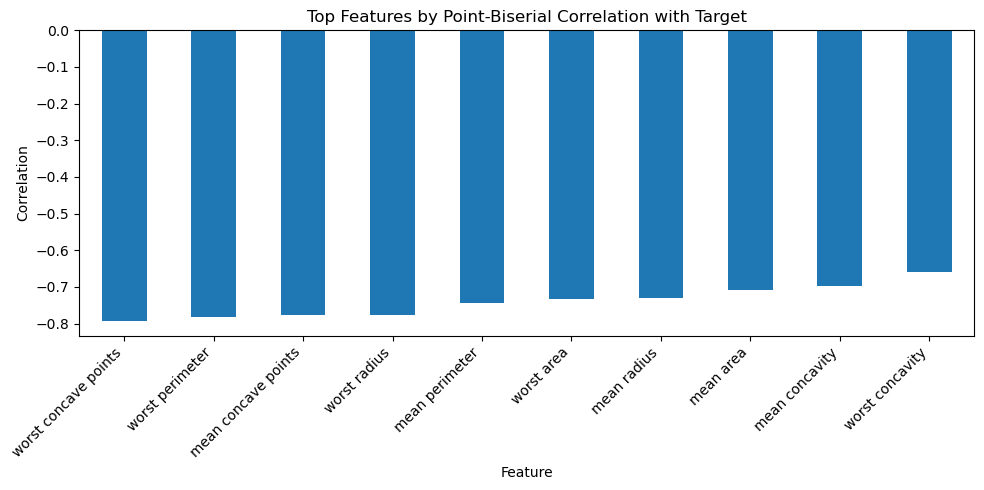

In [609]:
# Point-Biserial Correlation
pb_corr = {}

for col in feature_columns:
    corr, _ = pointbiserialr(feature_df[col], df['target'])
    pb_corr[col] = corr

corr_target = pd.Series(pb_corr).sort_values(key=lambda x: x.abs(), ascending=False)

# Plot top features
plt.figure(figsize=(10,5))
corr_target.head(10).plot(kind="bar")
plt.title("Top Features by Point-Biserial Correlation with Target")
plt.xlabel("Feature")
plt.ylabel("Correlation")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

The analysis reveals that several features exhibit strong statistical association with the tumour diagnosis.

The strongest correlations are observed for features describing tumour size and boundary irregularity. In particular, variables such as `worst concave points`, `worst perimeter`, `mean concave points`, and `worst radius` show the highest absolute correlations with the target variable.

All observed correlations are negative. This is expected because the target variable is encoded as 0 = malignant and 1 = benign. Larger values of these features therefore correspond to a higher likelihood of malignant tumours.

The results indicate that malignant tumours tend to exhibit larger cell nuclei and more irregular nuclear boundaries. Features related to concavity and concave points capture structural irregularities of the tumour cell border, while variables such as radius, perimeter, and area represent overall tumour size.

These findings are consistent with the dataset description and previous medical research on the Wisconsin Breast Cancer dataset, where geometric characteristics of cell nuclei were identified as important indicators for tumour malignancy. [4]

Overall, the results suggest that morphological measurements describing tumour size and structural irregularities provide strong predictive information for distinguishing malignant and benign tumour cases.

### 2.4.5 Feature Distribution Analysis

To further understand how features differ between malignant and benign tumours, the distributions of the most strongly correlated features were selected for visualization using boxplots and density plots.

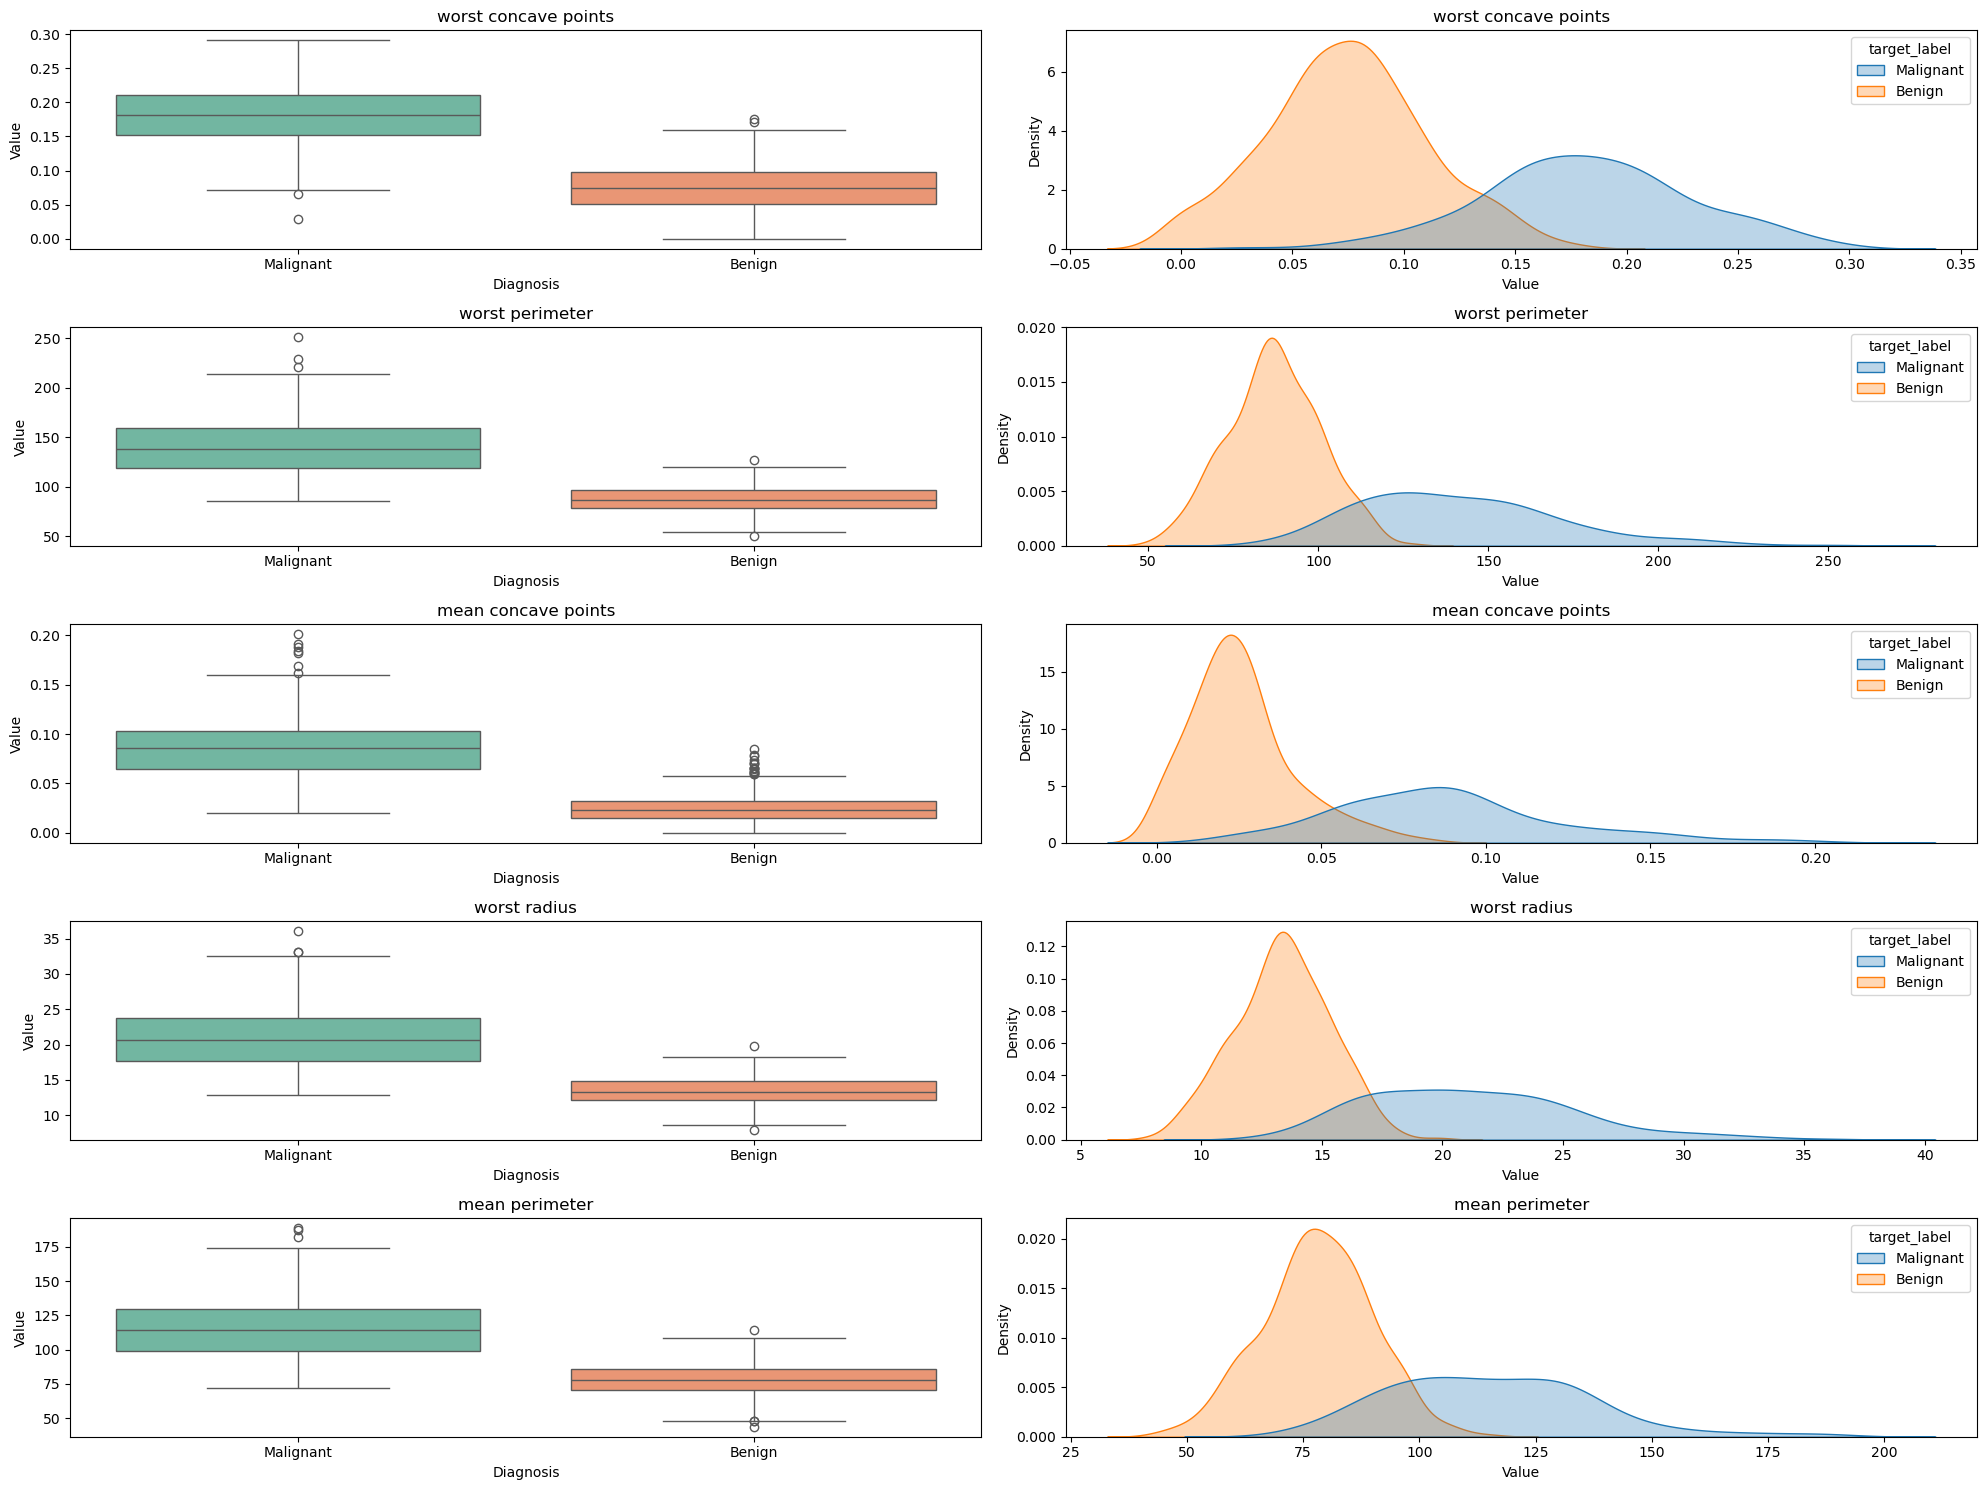

In [ ]:
top_features = corr_target.head(5).index.tolist()
n = len(top_features)

fig, axes = plt.subplots(n, 2, figsize=(20, 3 * n))
axes = np.atleast_2d(axes)

for i, feat in enumerate(top_features):

    sns.boxplot(data=df, x="target_label", y=feat, hue="target_label", palette="Set2", legend=False, ax=axes[i,0])

    axes[i,0].set_title(feat)
    axes[i,0].set_xlabel("Diagnosis")
    axes[i,0].set_ylabel("Value")

    sns.kdeplot(data=df, x=feat, hue="target_label", fill=True, alpha=0.3, ax=axes[i,1])
    
    axes[i,1].set_title(feat)
    axes[i,1].set_xlabel("Value")
    axes[i,1].set_ylabel("Density")

plt.tight_layout()
plt.show()

The boxplots and density plots show clear distribution differences between malignant and benign tumour cases for the selected top features.

In particular, features such as `worst concave points`, `worst perimeter`, `worst radius`, `mean perimeter`, and `mean concave points` display noticeable separation between the two classes. For all five features, malignant tumours tend to have higher values than benign tumours.

The boxplots also indicate that malignant cases often show a wider spread and more extreme observations, suggesting greater variability within this class. The density plots confirm these findings by showing shifted distributions with only partial overlap between malignant and benign cases.

Overall, these visual patterns support the earlier correlation analysis and suggest that measurements related to tumour size and boundary irregularity provide meaningful information for distinguishing malignant from benign tumours.

## 2.5 Key Observations

The data understanding phase provides several important insights into the structure and characteristics of the dataset.

**1. High data quality**

The dataset is complete and well-structured. No missing values or duplicate records were detected, and all predictor variables are numerical. This simplifies the data preparation phase because no data imputation or record removal is required.

**2. Differences in feature scale and distribution**

The descriptive statistics show that the variables differ in scale and distribution. Features related to tumour size, such as `area`, `perimeter`, and `radius`, have much larger numerical ranges than other variables. This indicates that feature scaling may be required for certain machine learning algorithms.

**3. Presence of strong feature correlations**

The correlation analysis revealed several highly correlated feature pairs, particularly among variables describing tumour size and related geometric properties. This indicates a degree of feature redundancy within the dataset and suggests that feature selection or regularisation techniques may be useful during model development.

**4. Strong association between morphological features and tumour diagnosis**

The point-biserial correlation analysis showed that several features are strongly associated with the target variable. In particular, measurements related to tumour size and boundary irregularity (such as radius, perimeter, area, and concave points) appear to be highly informative for distinguishing malignant from benign tumours.

**5. Clear distribution differences between tumour classes**

The feature distribution analysis demonstrated noticeable differences between malignant and benign tumour cases. Malignant tumours tend to exhibit larger values and greater variability for several morphological measurements. These patterns confirm that the extracted features contain meaningful diagnostic information and are suitable for machine learning classification tasks.

## References

[1] UCI Machine Learning Repository: Breast Cancer Wisconsin (Diagnostic) Dataset. Retrieved from https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)

[2] IBM Corporation (2011): IBM SPSS Modeler CRISP-DM Guide

[3] Aggarwal, C. C. (2017): Outlier Analysis (2nd Edition)

[4] Street, W. N.; Wolberg, W. H.; Mangasarian, O. L. (1993): Nuclear feature extraction for breast tumor diagnosis

[5] Sidey-Gibbons J. A. M.; Sidey-Gibbons, C. J. (2019): Machine learning in medicine: a practical introduction

[6] James, G.; Witten, D.; Hastie, T.; Tibshirani, R. (2013): An Introduction to Statistical Learning

[7] Cohen, J.; Cohen, P.; West, S. G.; Aiken, L. S. (2013): Applied Multiple Regression/Correlation Analysis for the Behavioral Sciences